In [15]:
import pandas as pd
import numpy as np
import os
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [9]:
#Load model and data

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

model=pickle.load(open(os.path.join('models','spam_classifier.pkl'),'rb'))
vectorizer=pickle.load(open(os.path.join('models','tfidf_vectorizer.pkl'),'rb'))

x_test=sp.load_npz(os.path.join('data','processed','x_test_tfidf.npz'))
y_test=pd.read_csv(os.path.join('data','processed','y_test.csv'))['label']

print('Model loaded!')

Model loaded!


In [11]:
#Predict the results
y_pred=model.predict(x_test)

In [12]:
#Show all metrices
print(f'Accuracy:{accuracy_score(y_test,y_pred):.4f}')
print(f'Prediction:{precision_score(y_test,y_pred):.4f}')
print(f'Recall:{recall_score(y_test,y_pred):.4f}')
print(f'F1 Score:{f1_score(y_test,y_pred):.4f}')

Accuracy:0.9623
Prediction:0.9908
Recall:0.7248
F1 Score:0.8372


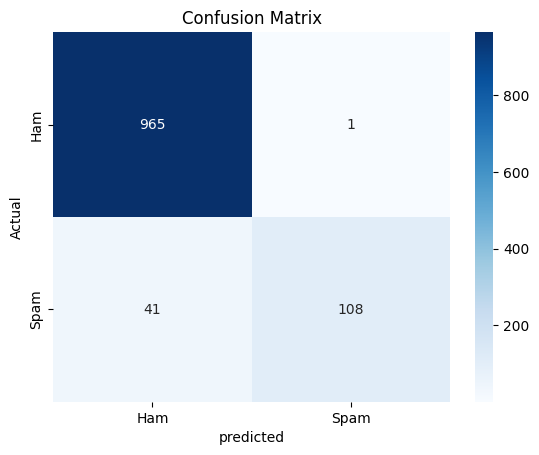

In [17]:
#Show Confusion Matrix
cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('predicted')
plt.savefig('reports/figures/confusion_matrix.png')
plt.show()



In [18]:
#Show Full Report
print(classification_report(y_test,y_pred,target_names=['Ham','Spam']))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [19]:
#Test by myself
def predict_message(message):
    clean=message.lower()
    vectorized=vectorizer.transform([clean])
    result=model.predict(vectorized)[0]
    return 'Spam' if result == 1 else 'Ham'

print(predict_message("FREE prize! Click now to win cash!"))
print(predict_message("Hey, are you coming to the meeting tomorrow?"))

Spam
Ham
